In [324]:
import pandas as pd

In [325]:
df = pd.read_csv('vk_eda/articles_match_status.csv')
df.head()

,article,status,brand,name,rating,reviews,n_mentions,total_likes,total_views,first_mention,last_mention
0,211466804,matched,wetty_lab,Крем для тела увлажняющий питательный для ухода,4.8,229.0,22,5,464,2024-12-18 15:29:51,2026-04-06 18:53:42
1,414386668,matched,art&fact,"Энзимная пудра для умывания с витамином C, 65 г",4.8,9933.0,9,360,8060,2025-07-29 10:35:59,2026-01-29 12:35:48
2,414386668,matched,art&fact,"Энзимная пудра для умывания с витамином C, 65 г",4.8,9935.0,9,360,8060,2025-07-29 10:35:59,2026-01-29 12:35:48
3,139625239,matched,vois,Пенка для умывания лица увлажняющая очищающая ...,4.8,86492.0,5,18,4693,2024-06-24 12:00:02,2025-04-27 07:40:00
4,139625239,matched,vois,Пенка для умывания лица увлажняющая очищающая ...,4.8,86492.0,5,18,4693,2024-06-24 12:00:02,2025-04-27 07:40:00


In [326]:
df[df['status'] == 'only_vk']

,article,status,brand,name,rating,reviews,n_mentions,total_likes,total_views,first_mention,last_mention
189,523231435,only_vk,NaN,NaN,NaN,NaN,6,383,11018,2025-10-30 08:54:26,2025-12-21 17:00:02
190,688613778,only_vk,NaN,NaN,NaN,NaN,3,118,6164,2025-01-22 15:36:34,2025-09-16 14:27:03
191,701890634,only_vk,NaN,NaN,NaN,NaN,3,30,4606,2025-12-17 08:40:16,2025-12-23 14:40:19
192,309272983,only_vk,NaN,NaN,NaN,NaN,3,227,18565,2025-01-31 14:08:12,2025-04-08 14:12:05
193,246538773,only_vk,NaN,NaN,NaN,NaN,2,113,7338,2024-12-12 16:00:48,2025-01-10 16:16:36
194,230900707,only_vk,NaN,NaN,NaN,NaN,2,11,2908,2024-11-12 09:00:01,2025-04-21 08:40:09
195,521169963,only_vk,NaN,NaN,NaN,NaN,2,76,1201,2025-12-08 11:10:00,2025-12-30 15:40:35
196,218602044,only_vk,NaN,NaN,NaN,NaN,2,73,3682,2025-05-27 09:30:17,2025-07-17 10:44:32
197,148822805,only_vk,NaN,NaN,NaN,NaN,2,0,1705,2024-11-15 15:30:00,2024-12-17 09:00:00
198,265293502,only_vk,NaN,NaN,NaN,NaN,2,12,1565,2024-10-14 08:51:22,2024-10-14 09:07:08


In [327]:
missed_article = set(df[df['status'] == 'only_vk']['article'].unique())

Сначала проверим, что отстутсвующие артикли пропали не из-за неправильного приведения брендов

In [328]:
df_first = pd.read_csv('parsed/wb_data.csv')
df_first.head()

,id,brand,name,price,old_price,discount,rating,reviews,link,search_url
0,695213222,ART&FACT.,Шампунь для жирных волос очищающий 400 мл,502,9462.0,NaN,"4,8",1264.0,https://www.wildberries.ru/catalog/695213222/d...,https://www.wildberries.ru/catalog/0/search.as...
1,791357100,ART&FACT.,"Сыворотка для лица с витамином С, набор 1+1",680,1710.0,NaN,"4,7",17219.0,https://www.wildberries.ru/catalog/791357100/d...,https://www.wildberries.ru/catalog/0/search.as...
2,44151357,ART&FACT.,"Лосьон для лица от акне и комедонов, 150 мл",525,2890.0,NaN,"4,7",10425.0,https://www.wildberries.ru/catalog/44151357/de...,https://www.wildberries.ru/catalog/0/search.as...
3,158573601,ART&FACT.,Пенка для умывания от прыщей,384,11020.0,NaN,"4,8",23762.0,https://www.wildberries.ru/catalog/158573601/d...,https://www.wildberries.ru/catalog/0/search.as...
4,694507304,ART&FACT.,"Шампунь для волос от выпадения, 400 мл",411,7753.0,NaN,"4,8",1264.0,https://www.wildberries.ru/catalog/694507304/d...,https://www.wildberries.ru/catalog/0/search.as...


In [329]:
len(missed_article)

47

In [330]:
len(set(df_first['id'].unique()) & missed_article)

0

Нет пересечений, поэтому спрасим только требуемые артикулы

In [331]:
import time
import csv
import logging
import os
import re
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

csv_file = "parsed/wb_missed_articles.csv"
log_file = "logs/wb_missed.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(log_file, encoding="utf-8"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

def clean_number(text):
    if not text:
        return ""
    return re.sub(r"[^\d.]", "", text).strip()

def load_existing_cards(csv_file):
    existing = set()
    if not os.path.exists(csv_file):
        return existing
    with open(csv_file, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            article = (row.get("article") or "").strip()
            if article:
                existing.add(article)
    return existing

def open_csv_for_append(csv_file):
    file_exists = os.path.exists(csv_file)
    csv_f = open(csv_file, "a", encoding="utf-8", newline="")
    fieldnames = ["article", "brand", "name", "price", "old_price", "rating", "reviews", "url"]
    writer = csv.DictWriter(csv_f, fieldnames=fieldnames)
    if not file_exists or os.path.getsize(csv_file) == 0:
        writer.writeheader()
    return csv_f, writer

def get_product_data(driver, article):
    url = f"https://www.wildberries.ru/catalog/{article}/detail.aspx"
    data = {
        "article": str(article),
        "brand": "",
        "name": "",
        "price": "",
        "old_price": "",
        "rating": "",
        "reviews": "",
        "url": url,
    }
    try:
        driver.get(url)
        WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
        driver.execute_script("window.scrollTo(0, 500)")
        time.sleep(3)

        try:
            name_el = driver.find_element(By.CSS_SELECTOR, "[class*='productTitle']")
            data["name"] = name_el.text.strip()
        except:
            try:
                name_el = driver.find_element(By.CSS_SELECTOR, "h1")
                data["name"] = name_el.text.strip()
            except:
                pass

        try:
            brand_el = driver.find_element(By.CSS_SELECTOR, "[class*='brandBadgeText']")
            data["brand"] = brand_el.text.strip()
        except:
            pass

        try:
            price_el = driver.find_element(By.CSS_SELECTOR, "[class*='priceBlockFinalPrice']")
            data["price"] = clean_number(price_el.text)
        except:
            try:
                price_el = driver.find_element(By.CSS_SELECTOR, "[class*='finalPrice']")
                data["price"] = clean_number(price_el.text)
            except:
                pass

        try:
            old_el = driver.find_element(By.CSS_SELECTOR, "[class*='priceBlockOldPrice']")
            data["old_price"] = clean_number(old_el.text)
        except:
            pass

        try:
            rating_el = driver.find_element(By.CSS_SELECTOR, "[class*='ratingNumberMinimized']")
            data["rating"] = rating_el.text.strip()
        except:
            try:
                rating_el = driver.find_element(By.CSS_SELECTOR, "[class*='ratingValue']")
                data["rating"] = rating_el.text.strip()
            except:
                pass

        try:
            rev_el = driver.find_element(By.CSS_SELECTOR, "[class*='feedbackCountMinimized']")
            data["reviews"] = clean_number(rev_el.text)
        except:
            try:
                rev_el = driver.find_element(By.CSS_SELECTOR, "[class*='reviewCount']")
                data["reviews"] = clean_number(rev_el.text)
            except:
                pass

    except Exception as e:
        logger.warning(f"Ошибка {article}: {e}")
    return data

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option("useAutomationExtension", False)
options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)

existing = load_existing_cards(csv_file)
csv_f, writer = open_csv_for_append(csv_file)

logger.info(f"Всего артикулов: {len(missed_article)}")
total_new = 0

for article in missed_article:
    art_str = str(article).strip()
    if not art_str or art_str in existing:
        logger.info(f"Пропускаем {art_str}")
        continue

    logger.info(f"Парсим {art_str}")
    data = get_product_data(driver, art_str)
    writer.writerow(data)
    csv_f.flush()
    total_new += 1
    existing.add(art_str)
    logger.info(f"Сохранён {art_str}")

logger.info(f"Добавлено: {total_new}")
csv_f.close()
driver.quit()

2026-04-10 23:17:02 - INFO - Всего артикулов: 47
2026-04-10 23:17:02 - INFO - Пропускаем 306061825
2026-04-10 23:17:02 - INFO - Пропускаем 142821506
2026-04-10 23:17:02 - INFO - Пропускаем 309017858
2026-04-10 23:17:02 - INFO - Пропускаем 309017861
2026-04-10 23:17:02 - INFO - Пропускаем 469666182
2026-04-10 23:17:02 - INFO - Пропускаем 311659017
2026-04-10 23:17:02 - INFO - Пропускаем 549253521
2026-04-10 23:17:02 - INFO - Пропускаем 688613778
2026-04-10 23:17:02 - INFO - Пропускаем 246162580
2026-04-10 23:17:02 - INFO - Пропускаем 246538773
2026-04-10 23:17:02 - INFO - Пропускаем 148822805
2026-04-10 23:17:02 - INFO - Пропускаем 309272983
2026-04-10 23:17:02 - INFO - Пропускаем 145541537
2026-04-10 23:17:02 - INFO - Пропускаем 381414567
2026-04-10 23:17:02 - INFO - Пропускаем 100105255
2026-04-10 23:17:02 - INFO - Пропускаем 12938793
2026-04-10 23:17:02 - INFO - Пропускаем 244994473
2026-04-10 23:17:02 - INFO - Пропускаем 521169963
2026-04-10 23:17:02 - INFO - Пропускаем 198705067
20

Избавимся от артикулов, которых нет на вб

In [332]:
wb = pd.read_csv('parsed/wb_missed_articles.csv')


In [333]:
wb = wb[wb['name'] != 'По Вашему запросу ничего не найдено'].copy()
wb.shape

(39, 8)

In [334]:
wb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39 entries, 0 to 46
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   article    39 non-null     int64  
 1   brand      0 non-null      float64
 2   name       38 non-null     object 
 3   price      17 non-null     float64
 4   old_price  18 non-null     float64
 5   rating     0 non-null      float64
 6   reviews    0 non-null      float64
 7   url        39 non-null     object 
dtypes: float64(5), int64(1), object(2)
memory usage: 2.7+ KB


Посмотрим на данные и избавимся от товаров, не связанных с косметикой

In [335]:
article_delete = [309017858, 309017861, 549253521, 688613778, 309272983, 309549871, 309582013, 309103821, 953399007, 772700896, 309104495, 380321650 ]
wb = wb[~wb['article'].isin(article_delete)].copy()
wb.shape

(27, 8)

Соединим их с уже имеющимися данными с вб

In [336]:
wb_before = pd.read_csv('wb_eda.csv')
wb_before.columns

Index(['id', 'brand', 'name', 'price', 'old_price', 'rating', 'reviews',
       'discount'],
      dtype='object')

In [337]:
wb.columns

Index(['article', 'brand', 'name', 'price', 'old_price', 'rating', 'reviews',
       'url'],
      dtype='object')

In [338]:
wb_before.rename(columns={'id': 'article'}, inplace=True)
wb.drop(columns=['url'], inplace=True)
wb['discount'] = (wb['old_price'] - wb['price']) / wb['old_price'] * 100

In [339]:
print(wb.columns)
print(wb_before.columns)

Index(['article', 'brand', 'name', 'price', 'old_price', 'rating', 'reviews',
       'discount'],
      dtype='object')
Index(['article', 'brand', 'name', 'price', 'old_price', 'rating', 'reviews',
       'discount'],
      dtype='object')


In [340]:
wb_all = pd.concat([wb, wb_before])
wb_all.columns

Index(['article', 'brand', 'name', 'price', 'old_price', 'rating', 'reviews',
       'discount'],
      dtype='object')

In [341]:
data = pd.read_csv('vk_eda/all_posts_clean.csv')
data = data.dropna(subset=['article'])
data = data[data['views_count'] >= data['likes_count']]
data['article'] = data['article'].astype('int')

data.head()

,brand,date,text,likes_count,comments_count,reposts_count,views_count,article_or_link,final_url,article,тип
1,artfact.products,2026-04-02 14:38:36,"Первое апреля прошло, а, значит, это точно не ...",24,2,0,1025,https://clc.to/SpQOHQ,https://www.wildberries.ru/catalog/884634860/d...,884634860,ссылка на WB
2,artfact.products,2026-03-31 09:00:21,Когда продукт становится не просто баночкой в ...,40,3,0,1000,https://vk.cc/cW35g2,https://www.wildberries.ru/catalog/760104825/d...,760104825,ссылка на WB
3,artfact.products,2026-03-26 12:28:16,Да кто такие эти ваши микроиглы? Без паники — ...,53,4,0,1014,https://vk.cc/cVU14O,https://www.wildberries.ru/catalog/807378841/d...,807378841,ссылка на WB
4,artfact.products,2026-03-24 09:00:09,У тебя тоже бывает так: стоишь перед зеркалом ...,34,0,1,793,https://vk.cc/cVOzit,https://www.wildberries.ru/catalog/695213222/d...,695213222,ссылка на WB
5,artfact.products,2026-03-23 08:48:52,Слышишь? Так звучит твой новый ASMR-ритуал 🤫🎧\...,33,0,2,440,https://vk.cc/cVMDzr,https://www.wildberries.ru/catalog/695213222/d...,695213222,ссылка на WB


In [342]:
data['brand'].unique()

array(['artfact.products', 'geltekcosmetics', 'iconskin', 'aravia',
       'theu_club', 'vois', 'mixit', 'wetty_lab'], dtype=object)

In [343]:
data['brand'] = 'art&fact' if 'artfact.products' in data['brand'] else data['brand']

In [344]:
all_df = pd.merge(data, wb_all, on='article', how='right')

In [345]:
all_df.columns

Index(['brand_x', 'date', 'text', 'likes_count', 'comments_count',
       'reposts_count', 'views_count', 'article_or_link', 'final_url',
       'article', 'тип', 'brand_y', 'name', 'price', 'old_price', 'rating',
       'reviews', 'discount'],
      dtype='object')

In [346]:
all_df.loc[all_df['brand_y'].isna(), 'brand_y'] = all_df.loc[all_df['brand_y'].isna(), 'brand_x']

all_df.drop(columns=['brand_x'], inplace = True)
all_df.rename(columns={'brand_y': 'brand'}, inplace = True)
all_df.columns

Index(['date', 'text', 'likes_count', 'comments_count', 'reposts_count',
       'views_count', 'article_or_link', 'final_url', 'article', 'тип',
       'brand', 'name', 'price', 'old_price', 'rating', 'reviews', 'discount'],
      dtype='object')

In [347]:
all_df.head()

,date,text,likes_count,comments_count,reposts_count,views_count,article_or_link,final_url,article,тип,brand,name,price,old_price,rating,reviews,discount
0,2025-04-14 12:06:59,"Мужчины тоже устают, и им требуется перерыв на...",72.0,1.0,0.0,2649.0,306061825,NaN,306061825,артикул,artfact.products,NaN,NaN,2444.0,NaN,NaN,NaN
1,2023-02-02 14:54:56,Особенная НОВИНКА 🤍 \n \nВ дерматологической с...,134.0,3.0,2.0,2532.0,https://vk.cc/clgCaM,https://www.wildberries.ru/catalog/142821506/d...,142821506,ссылка на WB,iconskin,Увлажняющий лосьон для чувствительной кожи лиц...,NaN,NaN,NaN,NaN,NaN
2,2025-08-12 12:49:42,"Продукт, который подарит коже красивый оттенок...",31.0,0.0,0.0,2732.0,https://vk.cc/cOwlZB,https://www.wildberries.ru/catalog/469666182/d...,469666182,ссылка на WB,geltekcosmetics,Капли автозагар для лица и тела концентрат,NaN,NaN,NaN,NaN,NaN
3,2025-02-25 09:20:07,Новинка: гидрофильный бальзам для умывания и с...,50.0,6.0,2.0,3081.0,https://vk.cc/cIVwyb,https://www.wildberries.ru/catalog/311659017/d...,311659017,ссылка на WB,geltekcosmetics,Гидрофильный бальзам щербет для умывания и сня...,1411.0,2098.0,NaN,NaN,32.745472
4,2024-12-19 16:04:55,Бесконечно можно смотреть на три вещи: как гор...,43.0,0.0,0.0,2679.0,246162580,NaN,246162580,артикул,artfact.products,Подарочный набор масок для лица,NaN,NaN,NaN,NaN,NaN


In [348]:
all_df.to_csv('analysis/wb_vk_eda.csv', index=False)

проверим наличие дублей по артикулам

In [349]:
d = all_df[all_df.duplicated(subset=['article'])]
d = d.sort_values(by='article')
d.head(10)

,date,text,likes_count,comments_count,reposts_count,views_count,article_or_link,final_url,article,тип,brand,name,price,old_price,rating,reviews,discount
11836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025412,NaN,lorealparis,Увлажняющая помада для губ COLOR RICHE оттенок...,602.0,1183.0,4.8,6370.0,49.112426
11810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025656,NaN,lorealparis,"Увлажняющая помада для губ COLOR RICHE, оттено...",590.0,1183.0,4.8,8372.0,50.126796
11832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025657,NaN,lorealparis,"Увлажняющая помада для губ COLOR RICHE, оттено...",602.0,1183.0,4.9,6497.0,49.112426
11892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025658,NaN,lorealparis,"Увлажняющая помада для губ COLOR RICHE, оттено...",857.0,1183.0,4.8,15163.0,27.557058
11813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025659,NaN,lorealparis,"Увлажняющая помада для губ COLOR RICHE, оттено...",613.0,1183.0,4.8,13410.0,48.182587
11982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025719,NaN,lorealparis,"Увлажняющая помада для губ COLOR RICHE, оттено...",706.0,1183.0,4.7,5783.0,40.321217
11658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3213308,NaN,lorealparis,Спрей для отросших корней Magic Retouch,392.0,669.0,4.9,89542.0,41.405082
6049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5551874,NaN,iconskin,Гель эмульсия энзимная от акне и воспалений,1447.0,2744.0,4.9,2346.0,47.266764
6077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5551875,NaN,iconskin,Крем для лица матирующий от воспалений SPF 10,1718.0,3438.0,4.9,1960.0,50.029087
6076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5551877,NaN,iconskin,Энзимная пудра для умывания лица очищающая,1537.0,2959.0,4.9,4708.0,48.056776


это товары у которых нет поста в вк, а они просто при парсинге были спаршены в разное времяб поэтому метрики товара на вб отличаются для одного артикула, оставим те, где метрика которая различается имеет наибольшее значение(например где успели накопиться еще отызвы)

In [350]:
all_df = all_df.sort_values(by='reviews', ascending=False)
all_df = all_df.drop_duplicates(subset=['article'], keep='first')

In [351]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [352]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9715 entries, 10420 to 12719
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             140 non-null    object 
 1   text             140 non-null    object 
 2   likes_count      140 non-null    float64
 3   comments_count   140 non-null    float64
 4   reposts_count    140 non-null    float64
 5   views_count      140 non-null    float64
 6   article_or_link  140 non-null    object 
 7   final_url        91 non-null     object 
 8   article          9715 non-null   int64  
 9   тип              140 non-null    object 
 10  brand            9715 non-null   object 
 11  name             9714 non-null   object 
 12  price            9699 non-null   float64
 13  old_price        9700 non-null   float64
 14  rating           7328 non-null   float64
 15  reviews          7328 non-null   float64
 16  discount         9699 non-null   float64
dtypes: float64(9),

In [353]:
all_df.isna().sum()

date               9575
text               9575
likes_count        9575
comments_count     9575
reposts_count      9575
views_count        9575
article_or_link    9575
final_url          9624
article               0
тип                9575
brand                 0
name                  1
price                16
old_price            15
rating             2387
reviews            2387
discount             16
dtype: int64

тут так много пропусков, так как существует по сути три группы товаров:
1.где товар упоминался в посте в вк(предполагаем, что будут успешнее всех)
2.бренды у которых есть хотя бы один пост в VK c артикулом на товар на вб(бустинг другого товара бренда может влиять на успех товара без упоминания)
3.бренды, товары которого в вк не продвигались никакние(то есть являющиеся контрольной группой для второго случая)


In [354]:
all_df['has_vk_post'] = all_df['text'].notna()
brands_with_vk = all_df[all_df['has_vk_post']]['brand'].unique()

def get_group(row):
    if row['has_vk_post']:
        return 'есть пост в VK'
    if  row['brand'] in brands_with_vk:
        return 'бренд есть в VK'
    return 'бренда нет в VK'

all_df['group'] = all_df.apply(get_group, axis=1)
all_df['group'].value_counts()

group
бренда нет в VK    5421
бренд есть в VK    4154
есть пост в VK      140
Name: count, dtype: int64

пропуски в date, text, likes_count и других вк колонках (12389 штук) обьясняются тем, что у этих товаров не было постов в вк
заполнять нулями нельзя тк 0 лайков и поста не было вообще - это разные вещи
3518 пропусков в rating и reviews это товары на wb у которых нет отзывов или парсер не достал, при анализе отзывов просто пропускаем их через dropna
28 пропусков в price это товары без цены, скорее всего сняты с продажи, их мало и они нас не интересуют, просто удаляем
1 пропуск в name один товар без названия, тоже удаляем, нас не интересует

In [355]:
all_df = all_df.dropna(subset=['price', 'name'])

посмотрим на распределение признаков по группам

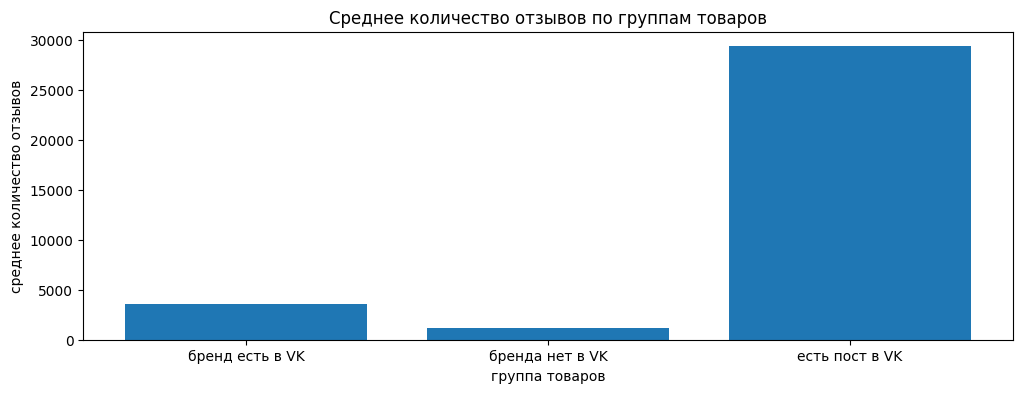

In [356]:
plt.figure(figsize=(12, 4))

group_reviews = all_df.groupby('group')['reviews'].mean().reset_index()

plt.bar(group_reviews['group'], group_reviews['reviews'])
plt.xlabel('группа товаров')
plt.ylabel('среднее количество отзывов')
plt.title('Среднее количество отзывов по группам товаров')
plt.show()

у группы есть пост в VK среднее число отзывов выше, это уже первый сигнал в пользу гипотезы: товары, которые продвигаются адресно, получают больше пользовательской активности на WB, для бизнеса это полезно, потому что отзывы - это не только метрика интереса, но и дополнительный фактор доверия к карточке товара

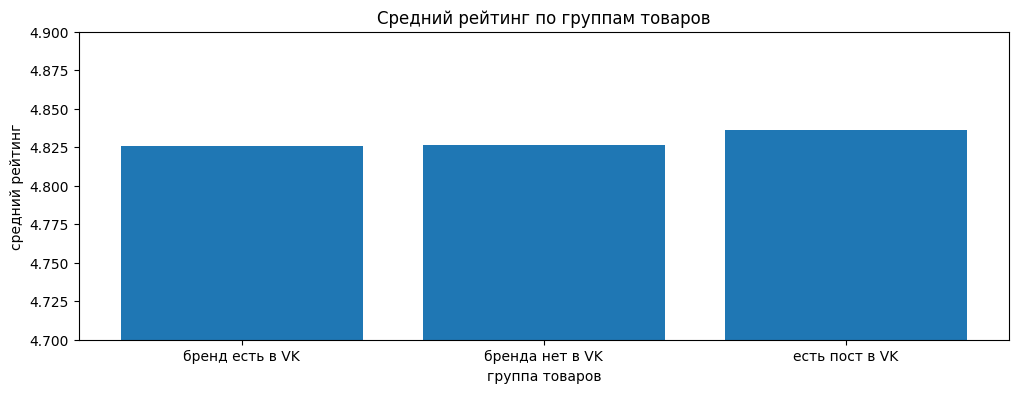

In [357]:
plt.figure(figsize=(12, 4))

group_rating = all_df.groupby('group')['rating'].mean().reset_index()

plt.bar(group_rating['group'], group_rating['rating'])
plt.ylim(4.7, 4.9)
plt.xlabel('группа товаров')
plt.ylabel('средний рейтинг')
plt.title('Средний рейтинг по группам товаров')
plt.show()

видим что рейтинг различается между группами слабее(но все еще группа где есть посты побеждает), продвижение в VK может быть связано скорее с ростом видимости и вовлечения, чем с радикальным изменением удовлетворенности товаром, для бизнеса это означает что вк скорее помогает усилить спрос и заметность товара, чем напрямую улучшает качество продукта, что логично

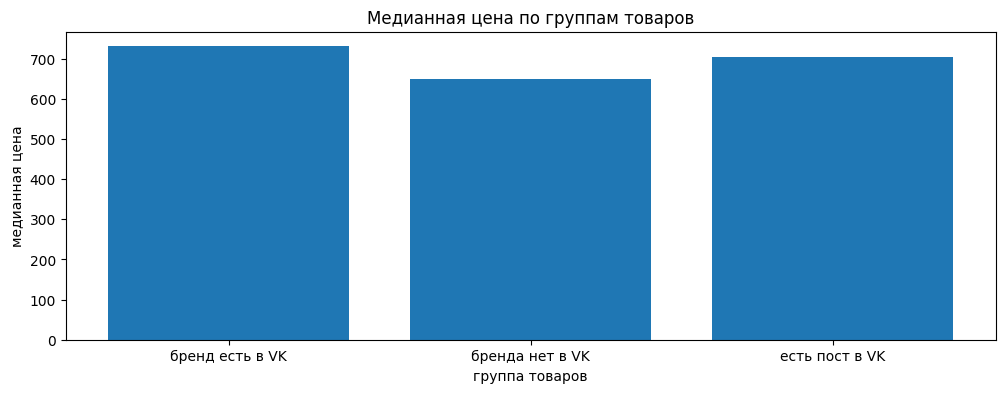

In [358]:
plt.figure(figsize=(12, 4))

group_price = all_df.groupby('group')['price'].median().reset_index()
plt.bar(group_price['group'], group_price['price'])
plt.xlabel('группа товаров')
plt.ylabel('медианная цена')
plt.title('Медианная цена по группам товаров')
plt.show()

товары с постами в вк одновременно заметно дороже или дешевле остальных, часть различий в спросе может объясняться не продвижением, а ценой, убедились, что не подменяем эффект вк эффектом от различия ценового сегмента

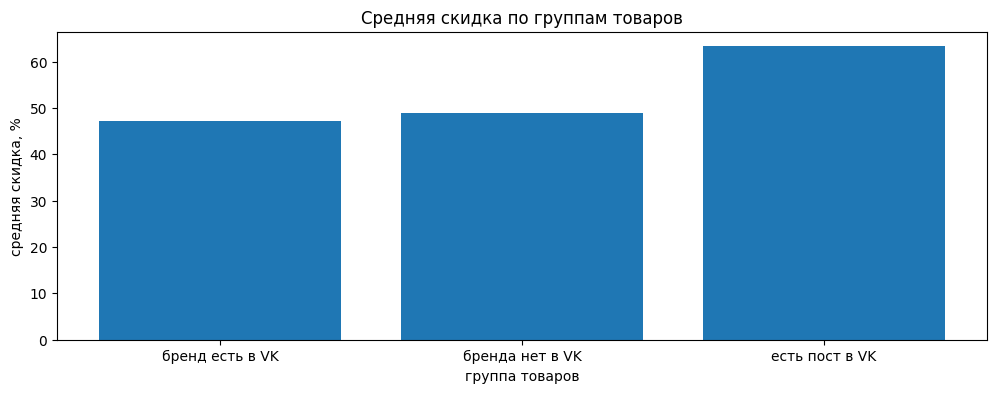

In [359]:
plt.figure(figsize=(12, 4))

group_discount = all_df.groupby('group')['discount'].mean().reset_index()
plt.bar(group_discount['group'], group_discount['discount'])
plt.xlabel('группа товаров')
plt.ylabel('средняя скидка, %')
plt.title('Средняя скидка по группам товаров')
plt.show()

группа с постами вк имеет более высокую среднюю скидку, значит рост отзывов или интереса может быть связан не только с соцсетью, но и с более агрессивной промо-механикой(то есть те кто занимаются продвижением в вк вероятно и одновременно делают скидки, чтобы их товар лучше продавался)

In [360]:
dif = []

for brand in brands_with_vk:
    brand_data = all_df[all_df['brand'] == brand]
    with_vk = brand_data[brand_data['has_vk_post']]
    without_vk = brand_data[~brand_data['has_vk_post']]
    
    if len(with_vk) > 0 and len(without_vk) > 0:
        dif.append({
            'brand': brand,
            'n_with_vk': with_vk['article'].nunique(),
            'n_without_vk': without_vk['article'].nunique(),
            'median_reviews_with_vk': with_vk['reviews'].median(),
            'median_reviews_without_vk': without_vk['reviews'].median(),
            'avg_rating_with_vk': with_vk['rating'].mean(),
            'avg_rating_without_vk': without_vk['rating'].mean(),
        })

table = pd.DataFrame(dif).round(1)
table

/Users/lesymizz/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,brand,n_with_vk,n_without_vk,median_reviews_with_vk,median_reviews_without_vk,avg_rating_with_vk,avg_rating_without_vk
0,vois,28,206,50607.0,7.5,4.8,4.8
1,art&fact,32,525,8347.0,2140.0,4.8,4.7
2,aravia,3,995,1214.0,329.5,4.8,4.9
3,mixit,16,1103,1027.0,482.5,4.8,4.8
4,geltekcosmetics,35,1031,544.0,132.0,4.9,4.8
5,iconskin,2,287,631.5,50.0,4.8,4.8
6,wetty_lab,1,4,229.0,10.5,4.8,4.9
7,theu_club,5,3,NaN,2365.0,NaN,4.8


по большинству брендов видно что товары, которые продвигаются в вк, в среднем собирают заметно больше отзывов на вб, чем товары без упоминаний, причём разница не просто есть, а во многих случаях кратная, что уже выглядит как потенциально значимый эффект
например, у geltekcosmetics медиана отзывов для товаров с вк примерно в 3–4 раза больше, у art&fact тоже более чем в три раза и тд

при этом важно учитывать, что по ряду брендов выборка с вк очень маленькая, поэтому там выводы менее надёжны и могут искажаться отдельными удачными или неудачными позициями, также есть случаи с пропусками, где нельзя сделать корректное сравнение
если смотреть на рейтинги, то значения практически одинаковые (в районе 4.8–4.9), то есть вк продвижение скорее связано именно с ростом активности (отзывы, заказы), а не с изменением восприятия качества товара

посмотрим на корреляцию активности аудитории под постом в вк и отзывами предположительно этих же клиентов на вб

In [361]:
vk_data = all_df[all_df['has_vk_post']].copy()

удалим выбросы по методу квантилей 

In [362]:
q_low_reviews = all_df['reviews'].quantile(0.01)
q_high_reviews = all_df['reviews'].quantile(0.99)

q_low_views = all_df['views_count'].quantile(0.01)
q_high_views = all_df['views_count'].quantile(0.99)

all_df= all_df[(all_df['reviews'] >= q_low_reviews) & (all_df['reviews'] <= q_high_reviews) &(all_df['views_count'] >= q_low_views) & (all_df['views_count'] <= q_high_views)]

посмотрим на матрицу корреляций признаков

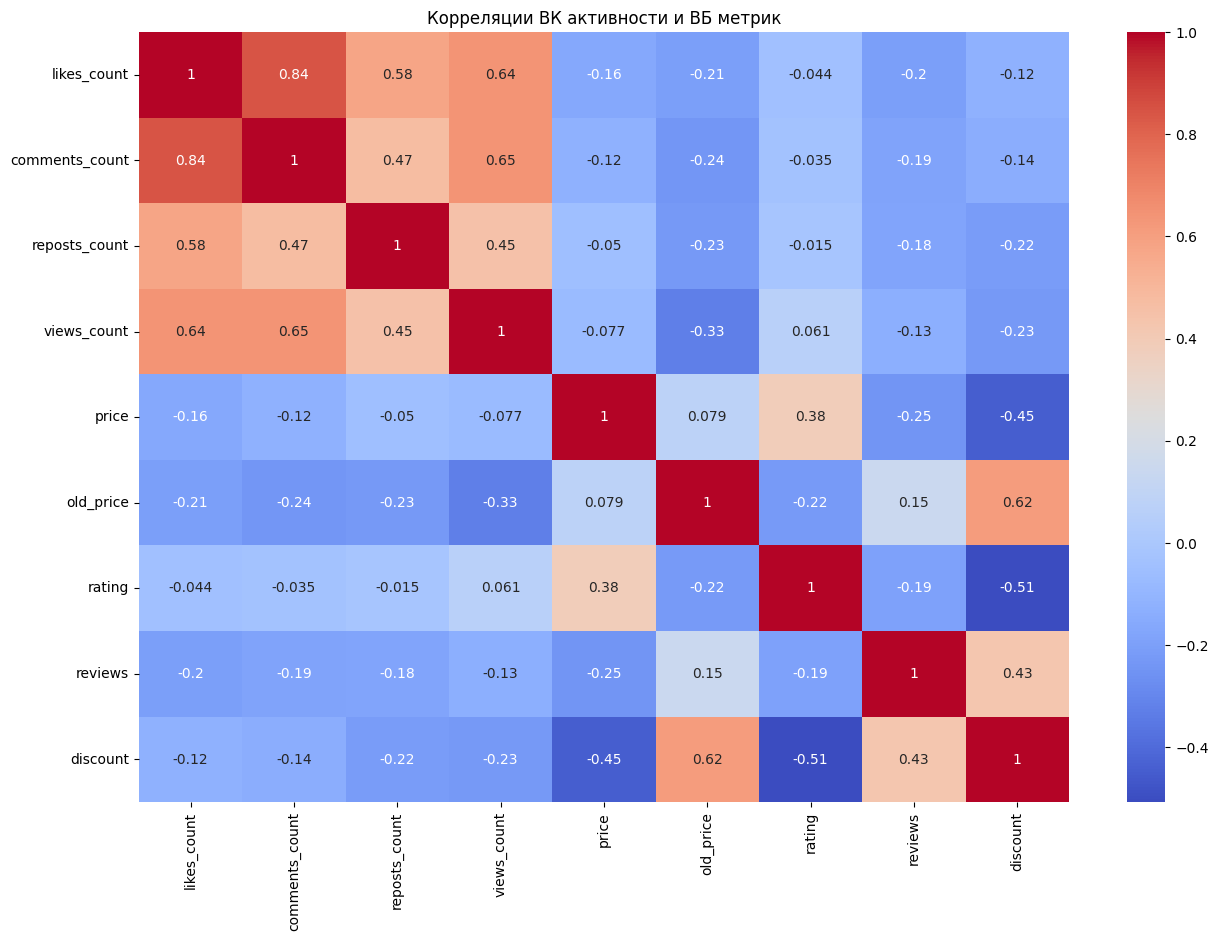

In [366]:
plt.figure(figsize=(15, 10))

corr_data = all_df.drop(columns=['article', 'has_vk_post'])
corr_matrix = corr_data.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title('Корреляции ВК активности и ВБ метрик')
plt.show()

метрики вк сильно коррелируют между собой(лайки и комментарии (0.84), лайки и просмотры (0.64), комментарии и просмотры (0.65), тк отражают один общий фактор вовлечённость аудитории)

скидка положительно связана с отзывами (0.43), что может говорить о том, что акции действительно стимулируют покупки, также наблюдается отрицательная связь скидки с ценой (-0.45) и рейтингом (-0.51), что может указывать на то, что более дешёвые или менее качественные товары чаще продаются со скидками, цена также отрицательно связана с отзывами (-0.25), то есть более дорогие товары в среднем получают меньше отзывов

ИТОГИ:

между группами брендов есть заметные различия в метриках вб, в среднем товары брендов, которые представлены в вк, чаще имеют большее количество отзывов, что может говорить о более высокой активности пользователей или узнаваемости таких брендов.
при этом эти различия не являются стабильными для всех брендов. внутри групп наблюдается большой разброс значений, и для части брендов эффект практически отсутствует, таким образом, на агрегированном уровне различия есть, но они не носят универсального характера и не позволяют однозначно говорить о влиянии вк для всех товаров

гипотеза о том, что вк продвижение влияет на удовлетворённость пользователей (рейтинг), не подтвердилась тк связь практически отсутствует

при этом подтвердилась гипотеза о влиянии скидок, они положительно связаны с количеством отзывов, а цена отрицательно, значит именно цена и акции являются более значимыми драйверами спроса, чем активность в вк